In [ ]:
!pip install datasets opencv-python scikit-learn tqdm

In [ ]:
from datasets import load_dataset

dataset = load_dataset("stochastic/random_streetview_images_pano_v0.0.2")

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:112: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


README.md:   0%|          | 0.00/6.85k [00:00<?, ?B/s]

dataset_infos.json:   0%|          | 0.00/974 [00:00<?, ?B/s]

data/train-00000-of-00006-9089804f14aacc(…):   0%|          | 0.00/472M [00:00<?, ?B/s]

data/train-00001-of-00006-bbdd122ad37de9(…):   0%|          | 0.00/470M [00:00<?, ?B/s]

data/train-00002-of-00006-f8ce946916e330(…):   0%|          | 0.00/469M [00:00<?, ?B/s]

data/train-00003-of-00006-f8e97309feb01a(…):   0%|          | 0.00/466M [00:00<?, ?B/s]

data/train-00004-of-00006-450fd3815b9251(…):   0%|          | 0.00/467M [00:00<?, ?B/s]

data/train-00005-of-00006-a0dd1c67775478(…):   0%|          | 0.00/465M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/11054 [00:00<?, ? examples/s]

In [ ]:
import random

data = dataset["train"]  # full dataset

# Shuffle
data = data.shuffle(seed=42)

# Split (same idea: 70/15/15)
train_size = int(0.7 * len(data))
val_size = int(0.15 * len(data))

train_data = data.select(range(train_size))
val_data = data.select(range(train_size, train_size + val_size))
test_data = data.select(range(train_size + val_size, len(data)))

print(len(train_data), len(val_data), len(test_data))

7737 1658 1659


In [ ]:
train_data = train_data.select(range(500))
test_data = test_data.select(range(100))

In [ ]:
sample = train_data[0]
print(sample)

{'image': <PIL.JpegImagePlugin.JpegImageFile image mode=RGB size=3030x561 at 0x7A77442B6180>, 'country_iso_alpha2': 'AE', 'latitude': '25.0027841', 'longitude': '55.1652137', 'address': 'Honeysuckle Pl - Dubai - Spojené arabské emiráty'}


(np.float64(-0.5), np.float64(3029.5), np.float64(560.5), np.float64(-0.5))

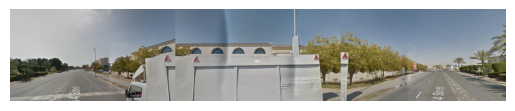

In [ ]:
import matplotlib.pyplot as plt

plt.imshow(sample["image"])
plt.axis("off")

In [ ]:
from PIL import Image
import numpy as np
import cv2

In [ ]:
RESIZE = 224
FEATURE_DIM = 50

# Vegetation HSV range (green)
VEG_H_LO = 35
VEG_H_HI = 85

# Driving side threshold
DRIVING_RATIO_THRESHOLD = 1.2

# Histogram bins
_H_BINS = 12
_S_BINS = 4
_V_BINS = 4

In [ ]:
def _brightness(gray):
    g = gray.astype(np.float64) / 255.0
    return np.array([g.mean(), g.std()], dtype=np.float64)


def _sky_mean_hsv(hsv):
    h, w, _ = hsv.shape
    cut = int(0.2 * h)
    strip = hsv[:cut, :, :].astype(np.float64)
    return strip.reshape(-1, 3).mean(axis=0)


def _hsv_histogram(h, s, v):
    h_hist, _ = np.histogram(h.ravel(), bins=_H_BINS, range=(0, 180))
    s_hist, _ = np.histogram(s.ravel(), bins=_S_BINS, range=(0, 256))
    v_hist, _ = np.histogram(v.ravel(), bins=_V_BINS, range=(0, 256))

    total = h.size

    return np.concatenate([
        h_hist / total,
        s_hist / total,
        v_hist / total
    ])

In [ ]:
def extract_features(img):
    rgb = np.asarray(img.convert("RGB"), dtype=np.uint8)

    rgb = cv2.resize(rgb, (RESIZE, RESIZE))
    bgr = cv2.cvtColor(rgb, cv2.COLOR_RGB2BGR)
    hsv = cv2.cvtColor(bgr, cv2.COLOR_BGR2HSV)

    h, s, v = hsv[:, :, 0], hsv[:, :, 1], hsv[:, :, 2]
    gray = cv2.cvtColor(bgr, cv2.COLOR_BGR2GRAY)

    sky = _sky_mean_hsv(hsv)
    hsv_hist = _hsv_histogram(h, s, v)
    bright = _brightness(gray)

    vec = np.concatenate([sky, hsv_hist, bright])

    # Normalize
    vec = vec.astype(np.float32)
    norm = np.linalg.norm(vec)

    if norm < 1e-6:
        return np.zeros_like(vec)

    return vec / norm

In [ ]:
sample = train_data[0]
features = extract_features(sample["image"])

print("Feature length:", len(features))
print(features)

Feature length: 25
[5.0310510e-01 3.0772629e-01 8.0755615e-01 3.6101195e-04 1.8032232e-03
 4.9998827e-04 5.2243671e-05 3.0713567e-05 6.9692243e-05 4.0070491e-04
 1.6870013e-03 1.3530295e-04 7.1426898e-06 7.0406513e-06 6.5814784e-05
 3.3595134e-03 1.4465988e-03 2.8519740e-04 2.8570759e-05 1.6020033e-04
 8.4049045e-04 3.6628735e-03 4.5631581e-04 2.8088551e-03 7.5001863e-04]


In [ ]:
X_train = []
y_train = []

for item in train_data:
    img = item["image"]
    lat = float(item["latitude"])
    lng = float(item["longitude"])

    feat = extract_features(img)

    X_train.append(feat)
    y_train.append([lat, lng])

import numpy as np
X_train = np.array(X_train, dtype=np.float32)
y_train = np.array(y_train, dtype=np.float32)

print("Train shape:", X_train.shape)

Train shape: (500, 25)


In [ ]:
X_val = []
y_val = []

for item in val_data:
    img = item["image"]
    lat = float(item["latitude"])
    lng = float(item["longitude"])

    feat = extract_features(img)

    X_val.append(feat)
    y_val.append([lat, lng])

X_val = np.array(X_val, dtype=np.float32)
y_val = np.array(y_val, dtype=np.float32)

In [ ]:
from sklearn.ensemble import RandomForestRegressor

rf = RandomForestRegressor(
    n_estimators=200,
    min_samples_leaf=3,
    n_jobs=-1,
    random_state=42
)

rf.fit(X_train, y_train)

RandomForestRegressor(min_samples_leaf=3, n_estimators=200, n_jobs=-1,
                      random_state=42)

In [ ]:
from sklearn.neighbors import KNeighborsRegressor

k_values = [3, 5, 10, 20]
knn_models = {}

for k in k_values:
    if k <= len(X_train):
        model = KNeighborsRegressor(n_neighbors=k, metric="cosine")
        model.fit(X_train, y_train)
        knn_models[k] = model

In [ ]:
from math import radians, sin, cos, sqrt, atan2
import numpy as np

def haversine(lat1, lon1, lat2, lon2):
    R = 6371
    dlat = radians(lat2 - lat1)
    dlon = radians(lon2 - lon1)

    a = sin(dlat/2)**2 + cos(radians(lat1)) * cos(radians(lat2)) * sin(dlon/2)**2
    c = 2 * atan2(sqrt(a), sqrt(1-a))

    return R * c

In [ ]:
def evaluate(model):
    errors = []

    for i in range(100):  # small subset for speed
        item = val_data[i]

        true_lat = float(item["latitude"])
        true_lng = float(item["longitude"])

        pred_lat, pred_lng = model.predict(
            [extract_features(item["image"])]
        )[0]

        error = haversine(true_lat, true_lng, pred_lat, pred_lng)
        errors.append(error)

    return np.median(errors)

In [ ]:
rf_error = evaluate(rf)
print("RF median:", rf_error)

knn_results = {}

for k, model in knn_models.items():
    err = evaluate(model)
    knn_results[k] = err
    print(f"KNN k={k}: {err:.2f} km")

RF median: 3954.681793560515
KNN k=3: 5122.29 km
KNN k=5: 4969.78 km
KNN k=10: 4596.11 km
KNN k=20: 4109.66 km


In [ ]:
best_knn_k = min(knn_results, key=knn_results.get)
best_knn_error = knn_results[best_knn_k]

if rf_error <= best_knn_error:
    best_model = rf
    model_name = "Random Forest"
else:
    best_model = knn_models[best_knn_k]
    model_name = f"KNN (k={best_knn_k})"

print("Selected model:", model_name)

Selected model: Random Forest


In [ ]:
X_all = np.vstack([X_train, X_val])
y_all = np.vstack([y_train, y_val])

best_model.fit(X_all, y_all)

RandomForestRegressor(min_samples_leaf=3, n_estimators=200, n_jobs=-1,
                      random_state=42)

In [ ]:
errors = []

for item in test_data.select(range(len(test_data))):
    img = item["image"]

    true_lat = float(item["latitude"])
    true_lng = float(item["longitude"])

    pred_lat, pred_lng = best_model.predict(
        [extract_features(img)]
    )[0]

    error = haversine(true_lat, true_lng, pred_lat, pred_lng)
    errors.append(error)

In [ ]:
errors = np.array(errors)

mean_error = np.mean(errors)
median_error = np.median(errors)

within_25 = np.mean(errors < 25) * 100
within_250 = np.mean(errors < 250) * 100
within_2500 = np.mean(errors < 2500) * 100

print(f"Mean error: {mean_error:.2f} km")
print(f"Median error: {median_error:.2f} km")

print(f"Within 25 km: {within_25:.2f}%")
print(f"Within 250 km: {within_250:.2f}%")
print(f"Within 2500 km: {within_2500:.2f}%")

Mean error: 5204.45 km
Median error: 3682.62 km
Within 25 km: 0.00%
Within 250 km: 0.00%
Within 2500 km: 26.00%


In [ ]:
sample = test_data[0]

pred = best_model.predict([extract_features(sample["image"])])[0]

print("Predicted:", pred)
print("Actual:", [sample["latitude"], sample["longitude"]])

Predicted: [33.62128883 23.73979829]
Actual: ['-46.1696478', '168.4474917']


In [ ]:
!pip install folium

In [ ]:
import folium

m = folium.Map(
    location=[pred_lat, pred_lng],
    zoom_start=8
)

folium.Marker(
    [pred_lat, pred_lng],
    popup="Predicted Location"
).add_to(m)

m

In [ ]:
import joblib

joblib.dump(best_model, "geolocation_model.pkl")

['geolocation_model.pkl']

In [ ]:
import joblib

best_model = joblib.load("geolocation_model.pkl")

In [ ]:
features = extract_features(img)

prediction = best_model.predict([features])

print(prediction)

[[22.60435283 43.66243733]]


In [ ]:
def predict_location(image_path):
    img = Image.open(image_path)

    features = extract_features(img)

    lat, lng = best_model.predict([features])[0]

    return lat, lng

In [ ]:
from google.colab import files

uploaded = files.upload()

Saving 1000003033.jpg to 1000003033.jpg


In [ ]:
filename = list(uploaded.keys())[0]
print(filename)

1000003033.jpg


In [ ]:
lat, lng = predict_location(filename)

print(f"Latitude: {lat}")
print(f"Longitude: {lng}")

Latitude: 20.642698643292512
Longitude: 47.40830320008884
